# exp02 - Сравнение моделей: Logistic Regression vs CatBoost

**Цель:** обучить и сравнить baseline (Logistic Regression) и финальную модель (CatBoost).

**Данные:** загружаем уже обработанный датасет `../data/processed_dataset.csv`

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, classification_report, RocCurveDisplay,
    ConfusionMatrixDisplay,
)

from catboost import CatBoostClassifier

RANDOM_STATE = 42

## 1. Загрузка обработанных данных

In [10]:
df = pd.read_csv('../data/processed_dataset.csv')
print(f'Размер: {df.shape}')
print(f'Дефолт-рейт: {df["loan_status"].mean():.2%}')
df.head(3)

Размер: (31522, 18)
Дефолт-рейт: 21.59%


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,monthly_payment_approx,debt_to_monthly_income,loan_grade_numeric,grade_rate_risk,is_homeowner,had_default
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,27.777778,0.034722,2,22.28,1,0
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,152.777778,0.190972,3,38.61,1,0
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,972.222222,0.178117,3,45.69,0,0


## 2. Разбивка и препроцессинг

In [11]:
NUMERIC_FEATURES = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
    'debt_to_monthly_income', 'loan_grade_numeric', 'grade_rate_risk', 
    'is_homeowner', 'had_default',
]

CATEGORICAL_FEATURES = [
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file',
]

TARGET = 'loan_status'

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
print(f'после препроцессинга: {X_train_prep.shape}')

Train: 25217, Test: 6305
после препроцессинга: (25217, 31)


## 3. Baseline: Logistic Regression

In [12]:
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_prep, y_train)

lr_pred = lr.predict(X_test_prep)
lr_prob = lr.predict_proba(X_test_prep)[:, 1]

lr_metrics = {
    'ROC-AUC':   round(roc_auc_score(y_test, lr_prob), 4),
    'F1':        round(f1_score(y_test, lr_pred), 4),
    'Precision': round(precision_score(y_test, lr_pred), 4),
    'Recall':    round(recall_score(y_test, lr_pred), 4),
    'Accuracy':  round(accuracy_score(y_test, lr_pred), 4),
}
print('Logistic Regression:')
print(pd.Series(lr_metrics).to_string())
print()
print(classification_report(y_test, lr_pred, target_names=['no_default', 'default']))

Logistic Regression:
ROC-AUC      0.8800
F1           0.6528
Precision    0.5606
Recall       0.7812
Accuracy     0.8205

              precision    recall  f1-score   support

  no_default       0.93      0.83      0.88      4943
     default       0.56      0.78      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



## 4. CatBoost

In [13]:
cb = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    l2_leaf_reg=3, 
    scale_pos_weight=3.0,
    random_seed=RANDOM_STATE, verbose=0,
)
cb.fit(X_train_prep, y_train)

cb_pred = cb.predict(X_test_prep)
cb_prob = cb.predict_proba(X_test_prep)[:, 1]

cb_metrics = {
    'ROC-AUC':   round(roc_auc_score(y_test, cb_prob), 4),
    'F1':        round(f1_score(y_test, cb_pred), 4),
    'Precision': round(precision_score(y_test, cb_pred), 4),
    'Recall':    round(recall_score(y_test, cb_pred), 4),
    'Accuracy':  round(accuracy_score(y_test, cb_pred), 4),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cb, X_train_prep, y_train, cv=cv, scoring='roc_auc')
print(f'CatBoost CV ROC-AUC: {cv_scores.mean():.4f} +- {cv_scores.std():.4f}')
print()
print('CatBoost:')
print(pd.Series(cb_metrics).to_string())
print()
print(classification_report(y_test, cb_pred, target_names=['no_default', 'default']))

CatBoost CV ROC-AUC: 0.9468 +- 0.0040

CatBoost:
ROC-AUC      0.9529
F1           0.8368
Precision    0.9009
Recall       0.7812
Accuracy     0.9342

              precision    recall  f1-score   support

  no_default       0.94      0.98      0.96      4943
     default       0.90      0.78      0.84      1362

    accuracy                           0.93      6305
   macro avg       0.92      0.88      0.90      6305
weighted avg       0.93      0.93      0.93      6305



## 5. Сравнение метрик

                     ROC-AUC      F1  Precision  Recall  Accuracy
Logistic Regression   0.8800  0.6528     0.5606  0.7812    0.8205
CatBoost              0.9529  0.8368     0.9009  0.7812    0.9342


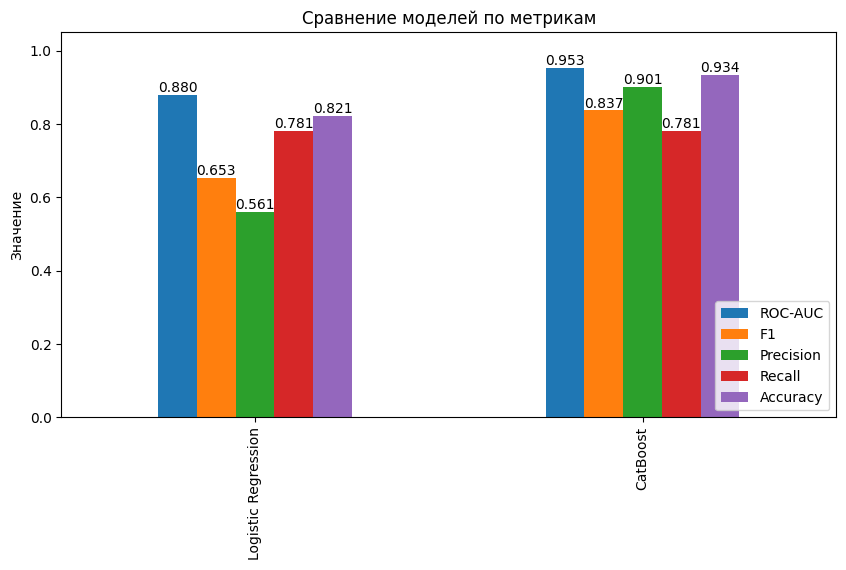

In [14]:
comparison = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'CatBoost': cb_metrics,
}).T

print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind='bar', ax=ax)
ax.set_title('Сравнение моделей по метрикам')
ax.set_ylabel('Значение')
ax.set_xticklabels(['Logistic Regression', 'CatBoost'])
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.savefig('../artifacts/model_comparison.png')
plt.show()

## 6. ROC-кривые

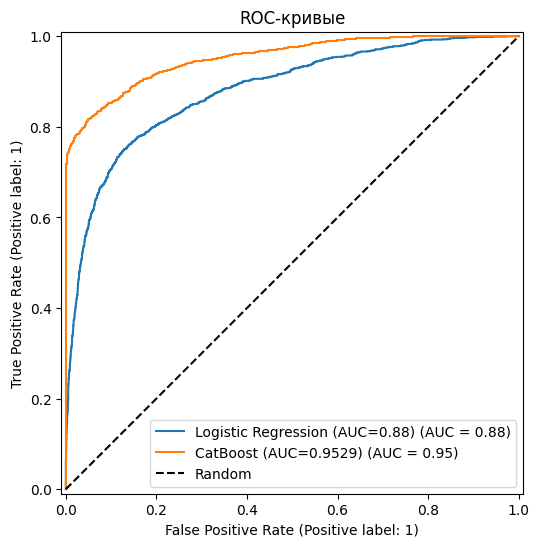

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, lr_prob, name=f'Logistic Regression (AUC={lr_metrics["ROC-AUC"]})', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, cb_prob, name=f'CatBoost (AUC={cb_metrics["ROC-AUC"]})', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC-кривые')
ax.legend(loc='lower right')
plt.savefig('../artifacts/roc_curves.png')
plt.show()

## 7. Матрицы ошибок

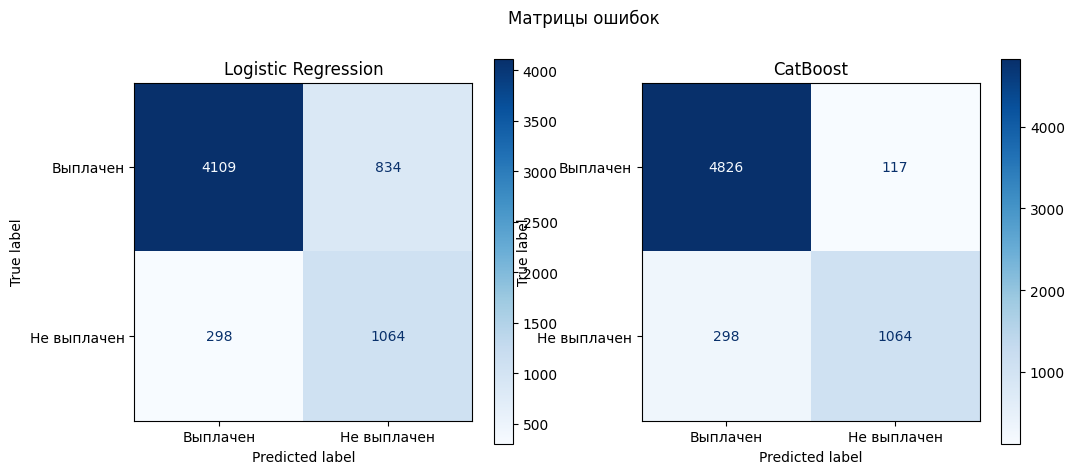

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Выплачен', 'Не выплачен'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, cb_pred,
    display_labels=['Выплачен', 'Не выплачен'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('CatBoost')

plt.suptitle('Матрицы ошибок')
plt.savefig('../artifacts/confusion_matrices.png')
plt.show()

## 8. Feature Importance (CatBoost)

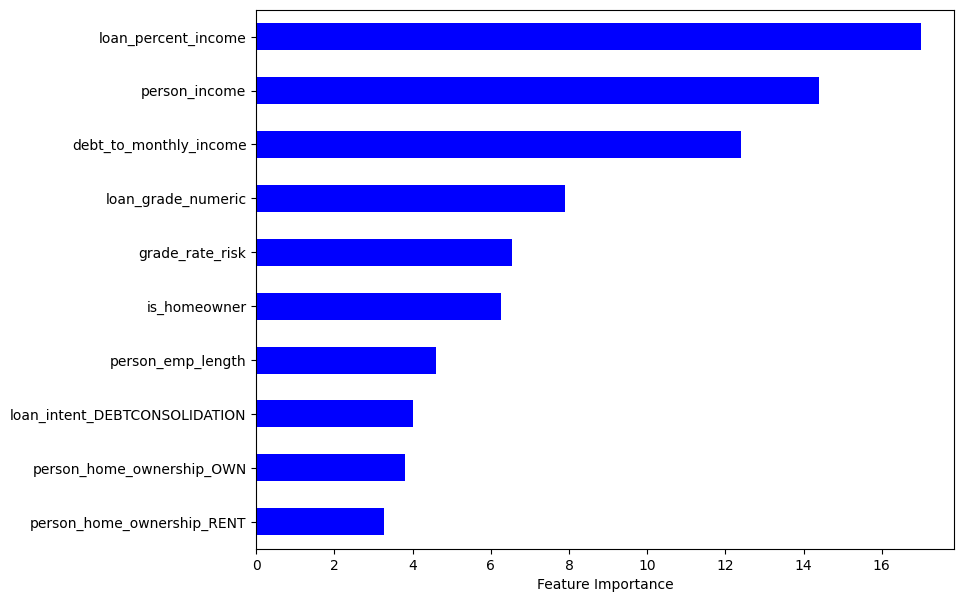

In [17]:
cat_feature_names = (
    preprocessor.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
all_feature_names = NUMERIC_FEATURES + cat_feature_names

importances = cb.get_feature_importance()
fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 7))
fi.sort_values().plot(kind='barh', ax=ax, color='blue')
ax.set_xlabel('Feature Importance')
plt.savefig('../artifacts/feature_importance.png')
plt.show()

## 9. Выводы

| Модель | ROC-AUC | F1 | Recall | Вывод |
|--------|---------|-----|--------|-------|
| Logistic Regression | 0.88 | 0.65 | 0.78 | Базовый уровень |
| CatBoost | 0.95 | 0.83 | 0.78 | Финальная модель |

CV ROC-AUC (CatBoost, 5-fold): 0.9468 +- 0.0040

**CatBoost выбран финальной моделью** по следующим причинам:
- Существенно лучше ROC-AUC (0.95 против 0.88). CatBoost точнее оценивает вероятность дефолта и разделяет классы
- При одинаковом Recall (0.78 у обеих моделей) Precision CatBoost составляет 0.90 против 0.56 у LR. На практике это прямые потери у LR - отказ надёжному клиенту
- Устойчивость CV ROC-AUC = 0.9468 +- 0.0040 - низкое стандартное отклонение

**Ключевые признаки** (по Feature Importance): `loan_grade_numeric`, `grade_rate_risk`,
`loan_int_rate`, `had_default`, `loan_percent_income`